In [21]:
import pandas as pd
data = pd.read_csv('/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv')

print(data.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [22]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [23]:
print(data.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [24]:
data = data.dropna()


In [25]:
print(data.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [26]:
data.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [27]:
data['Pass'] = (data['G3'] >= 10).astype(int)

In [28]:
X = data.drop(['G3', 'Pass'], axis=1)
y = data['Pass']

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8860759493670886


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9240506329113924


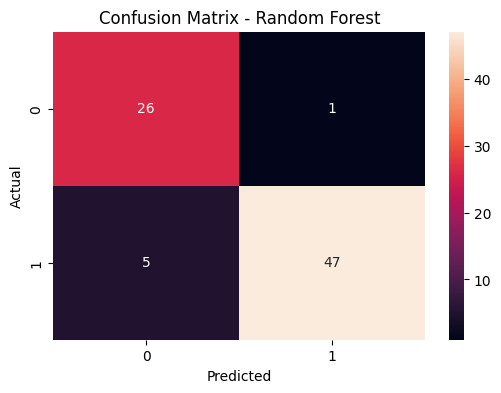

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

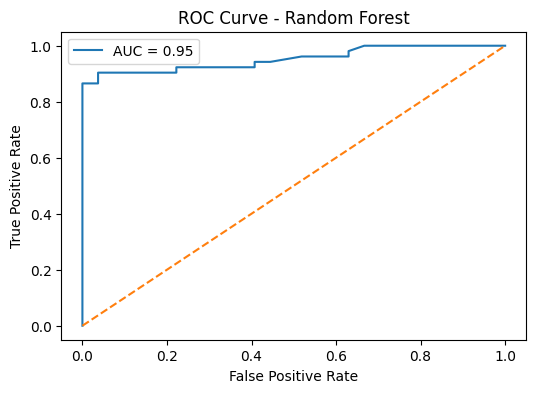

AUC Score: 0.9526353276353277


In [34]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

print("AUC Score:", roc_auc)

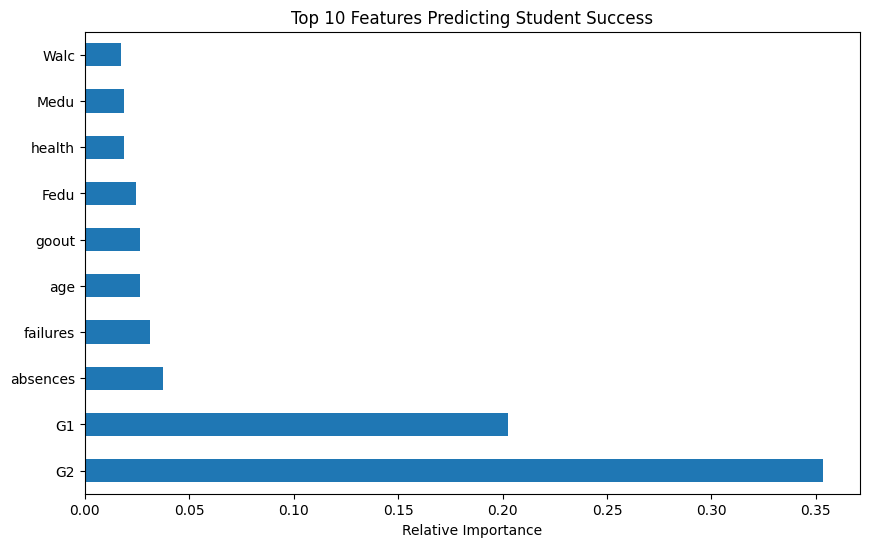

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features Predicting Student Success')
plt.xlabel('Relative Importance')
plt.show()

Accuracy without G1 & G2: 0.6582278481012658


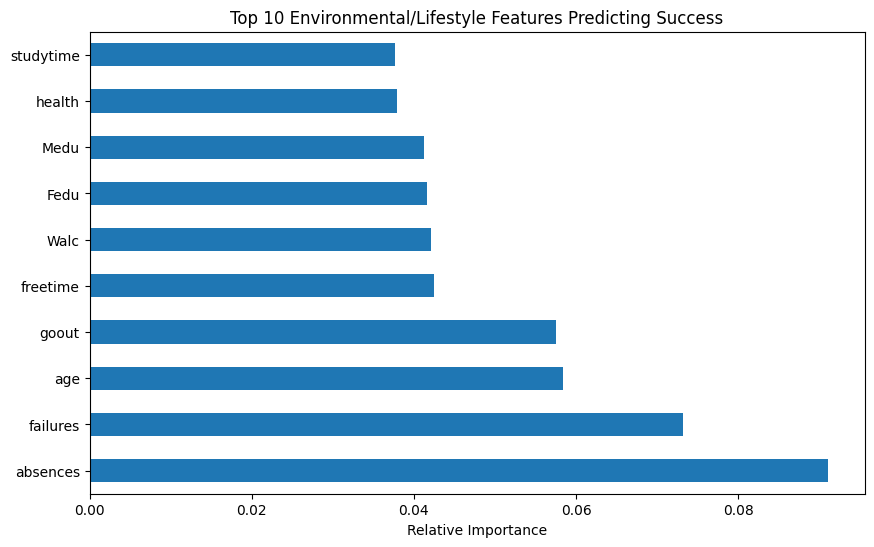

In [39]:
X_no_grades = data.drop(['G1', 'G2', 'G3', 'Pass'], axis=1)
y = data['Pass']

X_no_grades = pd.get_dummies(X_no_grades, drop_first=True)

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_no_grades, y, test_size=0.2, random_state=42
)

rf_no_grades = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_grades.fit(X_train_ng, y_train_ng)

ng_pred = rf_no_grades.predict(X_test_ng)
print("Accuracy without G1 & G2:", accuracy_score(y_test_ng, ng_pred))

importances_ng = rf_no_grades.feature_importances_
feat_importances_ng = pd.Series(importances_ng, index=X_no_grades.columns)

plt.figure(figsize=(10, 6))
feat_importances_ng.nlargest(10).plot(kind='barh')
plt.title('Top 10 Environmental/Lifestyle Features Predicting Success')
plt.xlabel('Relative Importance')
plt.show()

In [44]:
import numpy as np

importances_a = rf_model.feature_importances_
indices_a = np.argsort(importances_a)[-10:]
importances_b = rf_model_b.feature_importances_
indices_b = np.argsort(importances_b)[-10:]

In [45]:
X_b = X.drop(['G1', 'G2'], axis=1)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y, test_size=0.2, random_state=42
)

rf_model_b = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_b.fit(X_train_b, y_train_b)

y_pred_b = rf_model_b.predict(X_test_b)
print(f"Scenario B Random Forest Accuracy: {accuracy_score(y_test_b, y_pred_b) * 100:.1f}%")

Scenario B Random Forest Accuracy: 65.8%


Text(0.5, 0, 'Relative Importance')

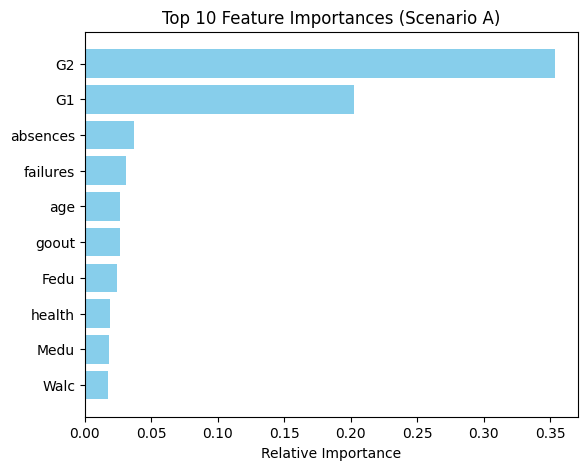

In [46]:

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.title('Top 10 Feature Importances (Scenario A)')
plt.barh(range(len(indices_a)), importances_a[indices_a], color='skyblue', align='center')
plt.yticks(range(len(indices_a)), [X.columns[i] for i in indices_a])
plt.xlabel('Relative Importance')


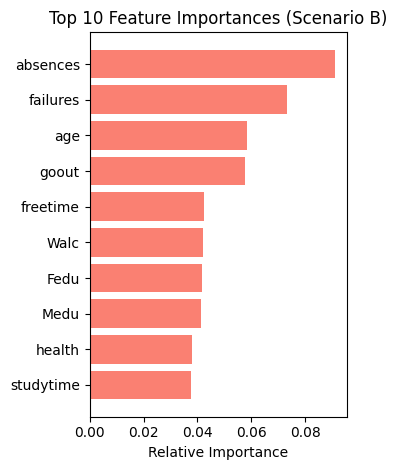

In [47]:

plt.subplot(1, 2, 2)
plt.title('Top 10 Feature Importances (Scenario B)')
plt.barh(range(len(indices_b)), importances_b[indices_b], color='salmon', align='center')
plt.yticks(range(len(indices_b)), [X_b.columns[i] for i in indices_b])
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()